In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('boston.csv')
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB




* CRIM: Per capita crime rate by town.
* ZN: Proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS: Proportion of non-retail business acres per town.
* CHAS: Charles River dummy variable (1 if tract borders the river; 0 otherwise).
* NOX: Nitric oxides concentration (parts per 10 million).
* RM: Average number of rooms per dwelling.
* AGE: Proportion of owner-occupied units built prior to 1940.
* DIS: Weighted distances to five Boston employment centres.
* RAD: Index of accessibility to radial highways.
* TAX: Full-value property-tax rate per $10,000.
* PTRATIO: Pupil-teacher ratio by town.
* B: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
* LSTAT: % lower status of the population.
* MEDV: Median value of owner-occupied homes in $$10,000.



In [4]:
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


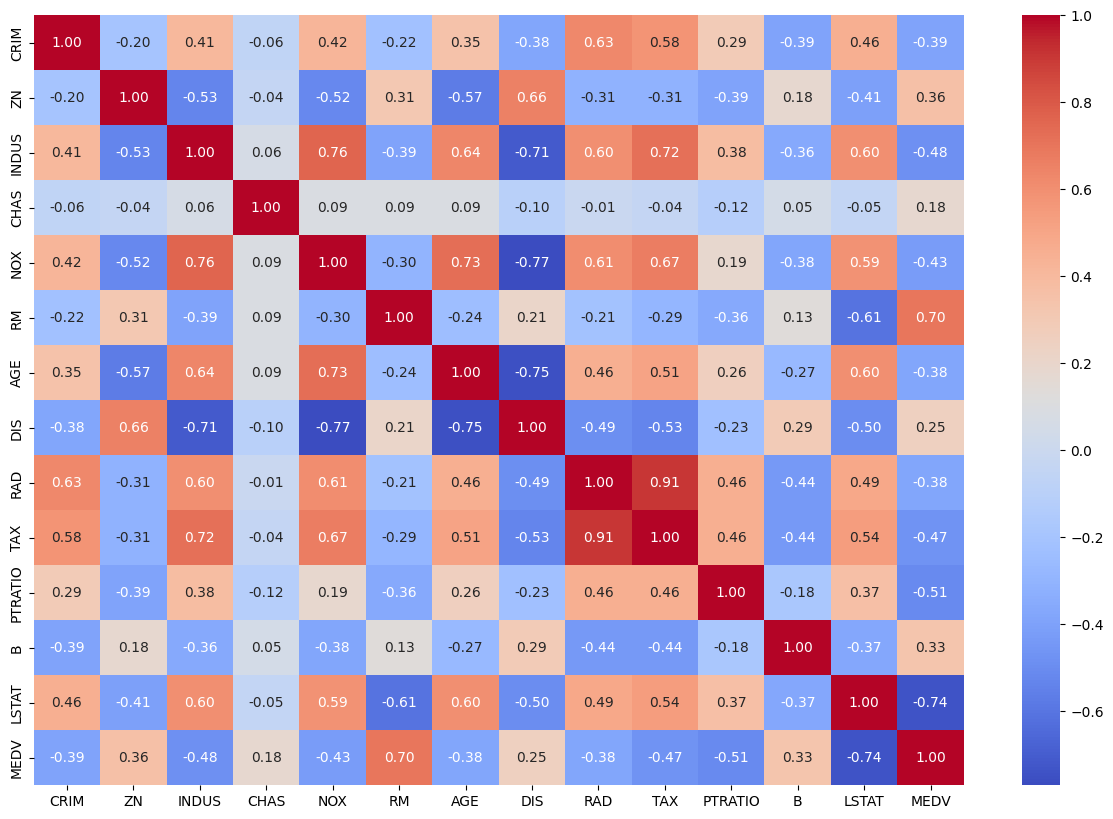

In [5]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr().round(2), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [6]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

In [7]:
X.shape

(506, 13)

In [8]:
Y.shape

(506,)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=20)

In [10]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((404, 13), (102, 13), (404,), (102,))

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [12]:
X_train=sc.fit_transform(X_train)

In [13]:
X_test=sc.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [15]:
reg.fit(X_train, Y_train)

LinearRegression()

In [16]:
y_pred = reg.predict(X_test)
y_pred

array([21.05690762, 27.54410192, 20.16232248, 23.91885465, 13.00416782,
       19.97164958, 17.74585525,  7.14393596, 18.91550072, 25.14388009,
       27.58099651, 15.86799568, 23.66924873, 21.50832445, 20.12745896,
       25.14885921, 31.19702709, 19.51664234, 14.51270678, 17.36388805,
       38.06837294, 42.54263219, 27.22576394, 32.41179632, 26.52857019,
       26.82709884, 19.98770946, 25.15283706, 21.28068136, 24.34416726,
       20.27481846, 17.23907825, 22.82269451,  9.58700562, 30.18955497,
       20.40165818, 42.65039536, 22.27926124, 19.51132656, 31.13475442,
        8.44358819, 16.84928291, 17.27751358, 12.95855964, 22.82880927,
       28.69986199, 21.57261236, 20.42222417,  9.6533953 , 13.04264469,
       34.70007391, 34.54219588, 11.26101887, 37.35085629, 19.33320964,
       22.49853816, 20.01774018, 20.03345887, 19.64956699, 23.03327128,
       27.68294932, 20.18597523, 19.33039843, 23.99956306, 17.56891876,
       18.63379892, 27.68490373, 25.80278039, 18.54275986, 17.90

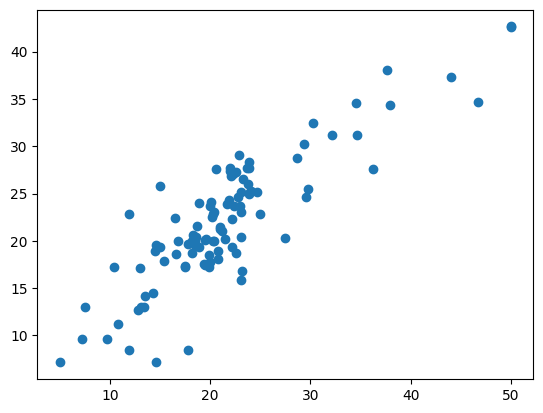

In [17]:
plt.scatter(Y_test, y_pred)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
print(mse, mae, rmse)

score = r2_score(Y_test, y_pred)
print("R2: ", score)

print("Adjusted R2: ", 1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))

16.49535197593168 3.0558941538909594 4.06144702980744
R2:  0.7438826183113533
Adjusted R2:  0.7060470960164396


In [19]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [20]:
reg.coef_

array([-0.56858806,  0.95897501,  0.32876157,  0.77313673, -2.44775239,
        2.6786234 ,  0.54009014, -2.88042407,  2.36720216, -1.89865586,
       -1.95557073,  0.85129913, -4.14413021])

In [21]:
import statsmodels.api as sm
model=sm.OLS(Y_train, X_train).fit()

In [22]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   MEDV   R-squared (uncentered):                   0.108
Model:                            OLS   Adj. R-squared (uncentered):              0.078
Method:                 Least Squares   F-statistic:                              3.645
Date:                Sun, 04 Jan 2026   Prob (F-statistic):                    1.83e-05
Time:                        03:59:45   Log-Likelihood:                         -1844.8
No. Observations:                 404   AIC:                                      3716.
Df Residuals:                     391   BIC:                                      3768.
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.5686      1.663     -0.342      0.733      -3.838       2.701
x2             0.9590      1.795      0.534      0.593      -2.569       4.487
x3             0.3288      2.400      0.137      0.891      -4.390       5.048
x4             0.7731      1.231      0.628      0.530      -1.648       3.194
x5            -2.4478      2.548     -0.961      0.337      -7.458       2.562
x6             2.6786      1.636      1.637      0.102      -0.539       5.896
x7             0.5401      2.150      0.251      0.802      -3.687       4.767
x8            -2.8804      2.386     -1.207      0.228      -7.571       1.810
x9             2.3672      3.140      0.754      0.451      -3.807       8.541
x10           -1.8987      3.436     -0.553      0.581      -8.655       4.857
x11           -1.9556      1.607     -1.217      0.225      -5.116       1.205
x12            0.8513      1.403      0.607      0.544      -1.908       3.610
x13           -4.1441      2.030     -2.041      0.042      -8.136      -0.153
==============================================================================
Omnibus:                      146.491   Durbin-Watson:                   0.085
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              594.882
Skew:                           1.567   Prob(JB):                    6.65e-130
Kurtosis:                       8.052   Cond. No.                         9.68
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Task
Please provide the new data you would like to predict on. This data should have the same 13 features as your original dataset (CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT). You can provide this as a list of lists, a Pandas DataFrame, or specify a file path to load it from.

## Prepare new data for prediction



In [23]:
## New data or New Input for prediction
new_data = [[0.02731, 0.0, 7.07, 0, 0.469, 6.421, 78.9, 4.9671, 2, 242.0, 17.8, 396.90, 9.14]]
print("New data for prediction:\n", new_data)

New data for prediction:
 [[0.02731, 0.0, 7.07, 0, 0.469, 6.421, 78.9, 4.9671, 2, 242.0, 17.8, 396.9, 9.14]]


**Reasoning**:
Before making predictions, the `new_data` must be scaled using the same `StandardScaler` that was used for the training data (`X_train`) to ensure consistency.



In [24]:
new_data_scaled = sc.transform(new_data)
print("Scaled new data:\n", new_data_scaled)

Scaled new data:
 [[-0.43999171 -0.5207382  -0.58814145 -0.28322059 -0.72704165  0.18139979
   0.38200183  0.53533961 -0.88094663 -1.00682729 -0.28084984  0.44969647
  -0.4714316 ]]


**Reasoning**:
With the new data now correctly scaled, I will use the trained linear regression model to predict the median house value for this new data point.



In [25]:
new_prediction = reg.predict(new_data_scaled)
print("Predicted MEDV for new data:", new_prediction[0])

Predicted MEDV for new data: 25.74387804924615


## Interpret the predicted values

### Subtask:
Interpret the predicted median house values (MEDV) for the new data points.


## Summary:

### Data Analysis Key Findings
*   A new data point for prediction was defined as `[[0.02731, 0.0, 7.07, 0, 0.469, 6.421, 78.9, 4.9671, 2, 242.0, 17.8, 396.90, 9.14]]`, representing the 13 features of the original dataset.
*   To ensure compatibility with the pre-fitted `StandardScaler`, the new data (initially a list of lists) was converted into a Pandas DataFrame with the correct feature names.
*   The `StandardScaler` successfully scaled the new data, making it ready for prediction.
*   The trained linear regression model predicted a Median House Value (MEDV) of approximately $25.74 for the provided new data point.

### Insights or Next Steps
*   Ensure that any new data used for prediction maintains the same structure and feature names as the training data to avoid compatibility issues with pre-fitted models and transformers.
*   The predicted value of $25.74 can now be used for decision-making or further analysis, potentially by comparing it to actual market values in similar areas.


In [26]:
# new_data = [[0.02321, 25.0, 6.90, 0, 0.7235, 10.954, 84, 5.2056, 4, 469.0, 19.09, 406.68, 11.67]]
new_data = [[0.023145, 22.0, 7.80, 0, 0.6965, 10.95, 84, 5.5454, 4, 469.0, 20.2121, 400.0, 11.54]]
print("Data for prediction: ", new_data)

Data for prediction:  [[0.023145, 22.0, 7.8, 0, 0.6965, 10.95, 84, 5.5454, 4, 469.0, 20.2121, 400.0, 11.54]]


In [27]:
scaled_data = sc.transform(new_data)
print("Scaled data: ", scaled_data)

Scaled data:  [[-0.44050391  0.4163586  -0.48392566 -0.28322059  1.24362061  6.52439854
   0.55810918  0.80341216 -0.65133215  0.33568717  0.83169044  0.48282052
  -0.14347683]]


In [28]:
new_pred = reg.predict(scaled_data)
print("Predicted MEDV: ", new_pred[0])

Predicted MEDV:  32.65487762310825


In [29]:

print("Data for prediction: ", new_data)

Data for prediction:  [[0.023145, 22.0, 7.8, 0, 0.6965, 10.95, 84, 5.5454, 4, 469.0, 20.2121, 400.0, 11.54]]


In [30]:
scaled_data = sc.transform(scaled_data)
print("Scaled Data: ", scaled_data)

Scaled Data:  [[-0.49752254 -0.50300328 -1.66655011 -1.3634345   5.98291706  0.3262125
  -2.32321045 -1.39474927 -1.18533875 -2.43606886 -8.10719527 -3.78609084
  -1.73999847]]


In [31]:
new_pred = reg.predict(scaled_data)
print("Predicted MEDV: ", new_pred[0])

Predicted MEDV:  31.615138099651503


In [32]:
new_data = [[0.02321, 25.0, 6.90, 0, 0.7235, 10.954, 84, 5.2056, 4, 469.0, 19.09, 406.68, 11.67]]
scaled_data = sc.transform(new_data)
pred = reg.predict(scaled_data)
print("Predicted value: ", pred)

Predicted value:  [33.63066072]
